# 03 — Text Analysis

In [1]:
import sys
sys.path.insert(0, "..")
import re
from collections import Counter

import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

from src import config, data_loader

df = data_loader.load_final_dataset()
texts = df["search_text"].tolist()
print(len(texts), "documents")


2026-09-01 22:02:06,045 | INFO     | src.data_loader | Loaded final dataset: 583 rows from E:\Job Base Programe\ResearchMind\data\processed\research_papers_final.csv


583 documents


## Word-frequency analysis

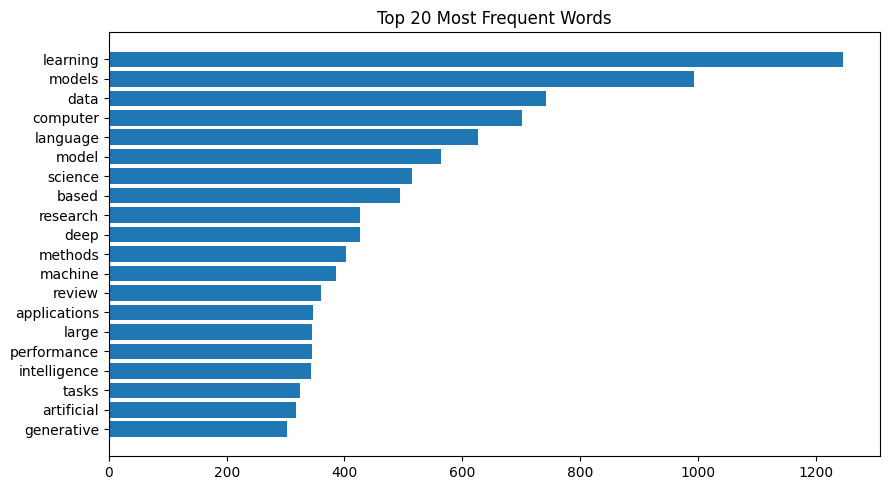

In [2]:
STOP = set(CountVectorizer(stop_words="english").get_stop_words())
words = []
for t in texts:
    words.extend(w for w in re.findall(r"[a-zA-Z]{3,}", t.lower()) if w not in STOP)

freq = Counter(words)
top_words = freq.most_common(20)
fig, ax = plt.subplots(figsize=(9, 5))
labels, counts = zip(*top_words)
ax.barh(labels[::-1], counts[::-1])
ax.set_title("Top 20 Most Frequent Words")
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "03_word_frequency.png", dpi=150)
plt.show()


## N-gram analysis (bigrams)

In [3]:
bigram_vec = CountVectorizer(ngram_range=(2, 2), stop_words="english", max_features=20)
bigram_counts = bigram_vec.fit_transform(texts).sum(axis=0)
bigrams = sorted(zip(bigram_vec.get_feature_names_out(), bigram_counts.tolist()[0]), key=lambda x: -x[1])
for phrase, count in bigrams[:15]:
    print(f"{count:>4}  {phrase}")


 465  computer science
 343  machine learning
 329  deep learning
 303  artificial intelligence
 246  language models
 226  natural language
 214  large language
 198  language processing
 197  computer vision
 192  generative ai
 162  federated learning
 116  state art
 108  explainable ai
  98  intelligence ai
  91  transformer models


## TF-IDF keyword extraction

In [4]:
tfidf = TfidfVectorizer(stop_words="english", max_features=5000, ngram_range=(1, 2))
tfidf_matrix = tfidf.fit_transform(texts)
mean_tfidf = tfidf_matrix.mean(axis=0).A1
top_idx = mean_tfidf.argsort()[::-1][:20]
feature_names = tfidf.get_feature_names_out()
for i in top_idx:
    print(f"{mean_tfidf[i]:.4f}  {feature_names[i]}")


0.0464  ai
0.0454  learning
0.0346  models
0.0290  language
0.0288  data
0.0229  model
0.0218  deep
0.0211  machine
0.0204  computer
0.0196  based
0.0194  machine learning
0.0185  research
0.0181  generative
0.0180  deep learning
0.0179  review
0.0175  methods
0.0174  applications
0.0171  xai
0.0170  vision
0.0169  large


## Abstract & title length distributions

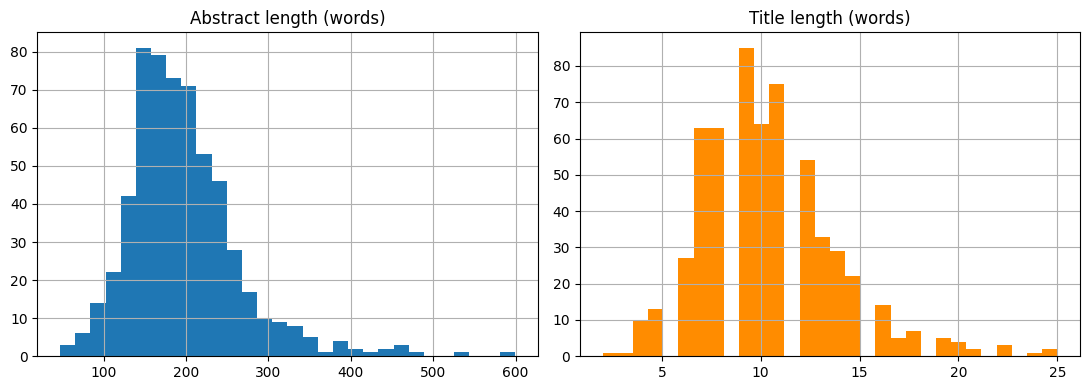

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
df["abstract"].astype(str).str.split().str.len().hist(bins=30, ax=axes[0])
axes[0].set_title("Abstract length (words)")
df["title"].astype(str).str.split().str.len().hist(bins=30, ax=axes[1], color="darkorange")
axes[1].set_title("Title length (words)")
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "03_length_distributions.png", dpi=150)
plt.show()


## Publication & citation trends over time

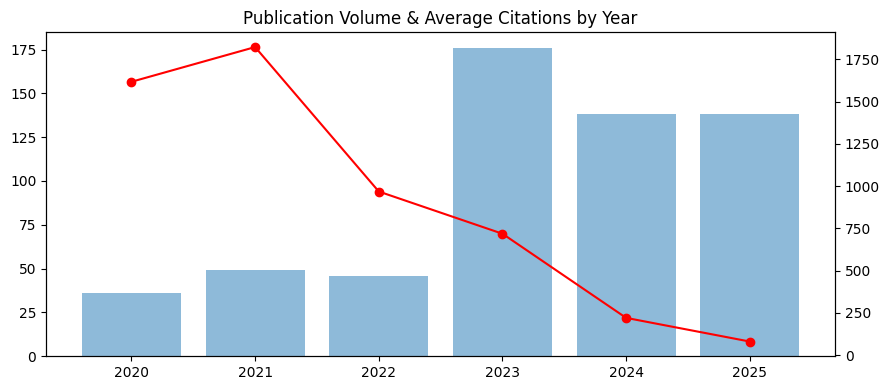

In [6]:
if "year" in df.columns and "citation_count" in df.columns:
    trend = df.groupby("year").agg(paper_count=("title", "count"), avg_citations=("citation_count", "mean"))
    fig, ax1 = plt.subplots(figsize=(9, 4))
    ax1.bar(trend.index, trend["paper_count"], alpha=0.5, label="Paper count")
    ax2 = ax1.twinx()
    ax2.plot(trend.index, trend["avg_citations"], color="red", marker="o", label="Avg citations")
    ax1.set_title("Publication Volume & Average Citations by Year")
    plt.tight_layout()
    plt.savefig(config.FIGURES_DIR / "03_publication_citation_trends.png", dpi=150)
    plt.show()


## Field-of-study distribution

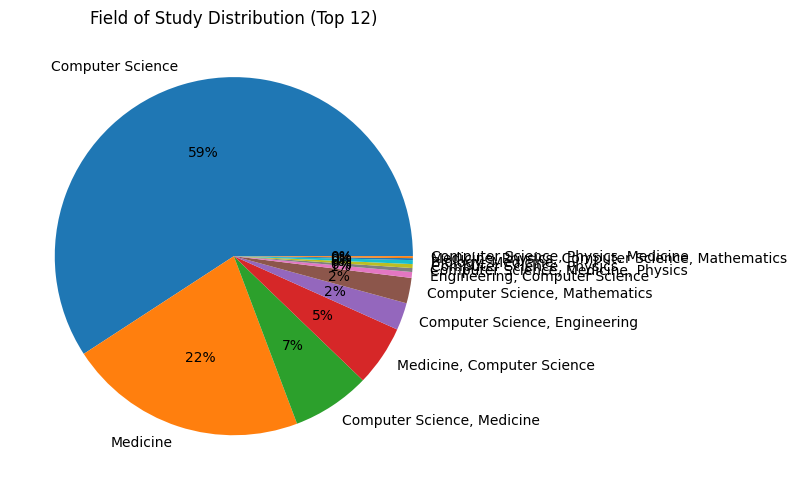

In [7]:
if "fields_of_study" in df.columns:
    dist = df["fields_of_study"].value_counts().head(12)
    fig, ax = plt.subplots(figsize=(8, 5))
    dist.plot(kind="pie", ax=ax, autopct="%1.0f%%")
    ax.set_ylabel("")
    ax.set_title("Field of Study Distribution (Top 12)")
    plt.tight_layout()
    plt.savefig(config.FIGURES_DIR / "03_field_distribution.png", dpi=150)
    plt.show()
